<a href="https://colab.research.google.com/github/DarkWhiteDarker/repos/blob/main/under_water_creature_detection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import tensorflow as tf
import plotly as plty
import kagglehub
import os
from pathlib import Path
import cv2
import yaml

In [1]:
path = kagglehub.dataset_download("akshatsng/underwater-dataset-for-8-classes-with-label")

100%|██████████| 28.3M/28.3M [00:00<00:00, 101MB/s] 

Extracting files...


In [3]:
import os

# Print the exact path where kagglehub saved your data
print("Dataset downloaded to:", path)

# List the contents of that directory to see how it's structured
print("\nDirectory contents:")
print(os.listdir(path))

Dataset downloaded to: /root/.cache/kagglehub/datasets/akshatsng/underwater-dataset-for-8-classes-with-label/versions/1

Directory contents:
['README.roboflow.txt', 'README.dataset.txt', 'valid', 'test', 'train', 'data.yaml']


In [31]:
import pandas as pd
import numpy as np

# 1. Extract global statistical metrics per image
mean_r = np.mean(X_train[:, :, :, 0], axis=(1, 2))  # Average Red intensity
mean_g = np.mean(X_train[:, :, :, 1], axis=(1, 2))  # Average Green intensity
mean_b = np.mean(X_train[:, :, :, 2], axis=(1, 2))  # Average Blue intensity
contrast = np.std(X_train, axis=(1, 2, 3))          # Pixel standard deviation (Contrast)

# 2. Map class IDs to their string names for clean plot labels
mapped_labels = [class_names[idx] for idx in y_train]

# 3. Construct the Tabular EDA DataFrame
df_eda = pd.DataFrame({
    'Mean_Red': mean_r,
    'Mean_Green': mean_g,
    'Mean_Blue': mean_b,
    'Contrast': contrast,
    'Class_ID': y_train,
    'Class_Name': mapped_labels
})

print("--- EXTRACTED EDA DATAFRAME SAMPLE ---")
print(df_eda.head())

--- EXTRACTED EDA DATAFRAME SAMPLE ---
     Mean_Red  Mean_Green   Mean_Blue   Contrast  Class_ID  Class_Name
0   58.894409  109.471802  133.766663  68.312976         0  Coral Reef
1  132.680176  154.347900  116.648010  75.433774         0  Coral Reef
2   86.568542  153.861206  143.085388  72.386923         0  Coral Reef
3   74.768127  120.507202  151.306030  80.792081         0  Coral Reef
4  129.969604  112.292480   81.216187  70.691482         0  Coral Reef


/tmp/ipykernel_560/1649848305.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Class_Name', y='Contrast', palette='Pastel1')


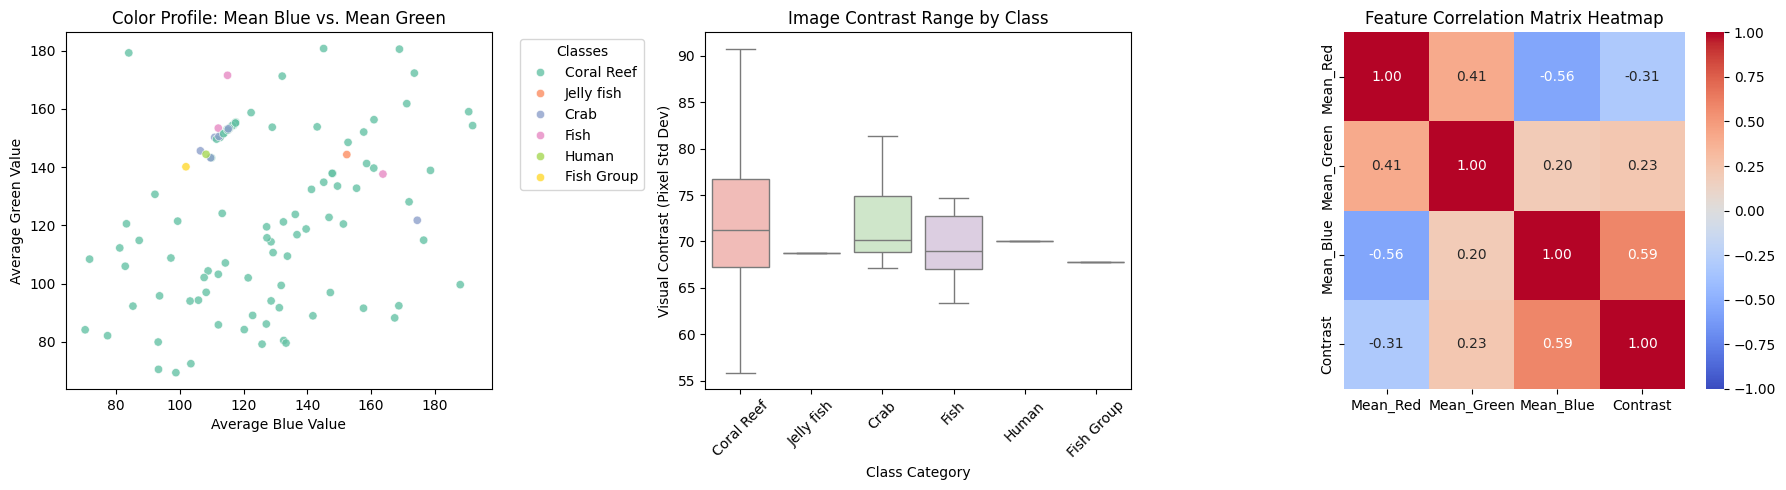

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

# 1. Scatter Plot: Color Channel Interactions
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_eda, x='Mean_Blue', y='Mean_Green', hue='Class_Name', palette='Set2', alpha=0.8)
plt.title('Color Profile: Mean Blue vs. Mean Green')
plt.xlabel('Average Blue Value')
plt.ylabel('Average Green Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Classes')

# 2. Box Plot: Contrast Distribution across Categories
plt.subplot(1, 3, 2)
# Using unique classes present in training to prevent plotting empty slots
sns.boxplot(data=df_eda, x='Class_Name', y='Contrast', palette='Pastel1')
plt.title('Image Contrast Range by Class')
plt.xlabel('Class Category')
plt.ylabel('Visual Contrast (Pixel Std Dev)')
plt.xticks(rotation=45)

# 3. Heatmap: Feature Correlation Matrix
plt.subplot(1, 3, 3)
numerical_cols = ['Mean_Red', 'Mean_Green', 'Mean_Blue', 'Contrast']
corr_matrix = df_eda[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix Heatmap')

plt.tight_layout()
plt.show()

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Define independent features (X) and target variable (Y)
X_reg = df_eda[['Mean_Red', 'Mean_Green', 'Mean_Blue']]
y_reg = df_eda['Contrast']

# Initialize and fit the Multiple Linear Regression model
mlr_model = LinearRegression()
mlr_model.fit(X_reg, y_reg)

# Generate predictions for metric evaluation
y_pred_reg = mlr_model.predict(X_reg)

print("="*50)
print("MULTIPLE LINEAR REGRESSION ANALYSIS RESULTS")
print("="*50)
print(f"Intercept (Beta 0): {mlr_model.intercept_:.4f}\n")
print("Regression Coefficients:")
for col, coef in zip(X_reg.columns, mlr_model.coef_):
    print(f"  -> {col:12}: {coef:.4f}")

print("-"*50)
print(f"R-squared Score (R²): {r2_score(y_reg, y_pred_reg):.4f}")
print(f"Mean Squared Error   : {mean_squared_error(y_reg, y_pred_reg):.4f}")
print("="*50)

MULTIPLE LINEAR REGRESSION ANALYSIS RESULTS
Intercept (Beta 0): 52.8843

Regression Coefficients:
  -> Mean_Red    : -0.0170
  -> Mean_Green  : 0.0404
  -> Mean_Blue   : 0.1241
--------------------------------------------------
R-squared Score (R²): 0.3667
Mean Squared Error   : 27.4237


In [4]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [6]:
train_path = Path(path) / 'train'
print(f"Checking contents of: {train_path}")
print(os.listdir(train_path))
subfolders =[f.name for f in train_path.iterdir() if f.is_dir()]
print("\nsubfolders found inside 'train':" , subfolders)

Checking contents of: /root/.cache/kagglehub/datasets/akshatsng/underwater-dataset-for-8-classes-with-label/versions/1/train
['images', 'labelTxt']

subfolders found inside 'train': ['images', 'labelTxt']


In [11]:
yaml_path = Path(path) / 'data.yaml'

with open(yaml_path, 'r') as file:
    dataset_info = yaml.safe_load(file)

# Extract class names
if 'names' in dataset_info:
    class_names = dataset_info['names']
    print("Your 7 Underwater Classes are:")
    for idx, name in enumerate(class_names):
        print(f" Class {idx}: {name}")
else:
    print("Could not find class names in data.yaml. Content:")
    print(dataset_info)

Your 7 Underwater Classes are:
 Class 0: Coral Reef
 Class 1: Crab
 Class 2: Fish
 Class 3: Fish Group
 Class 4: Human
 Class 5: Jelly fish
 Class 6: Trash


Loading and parsing training data... Please wait.
Successfully loaded 114 classification images!


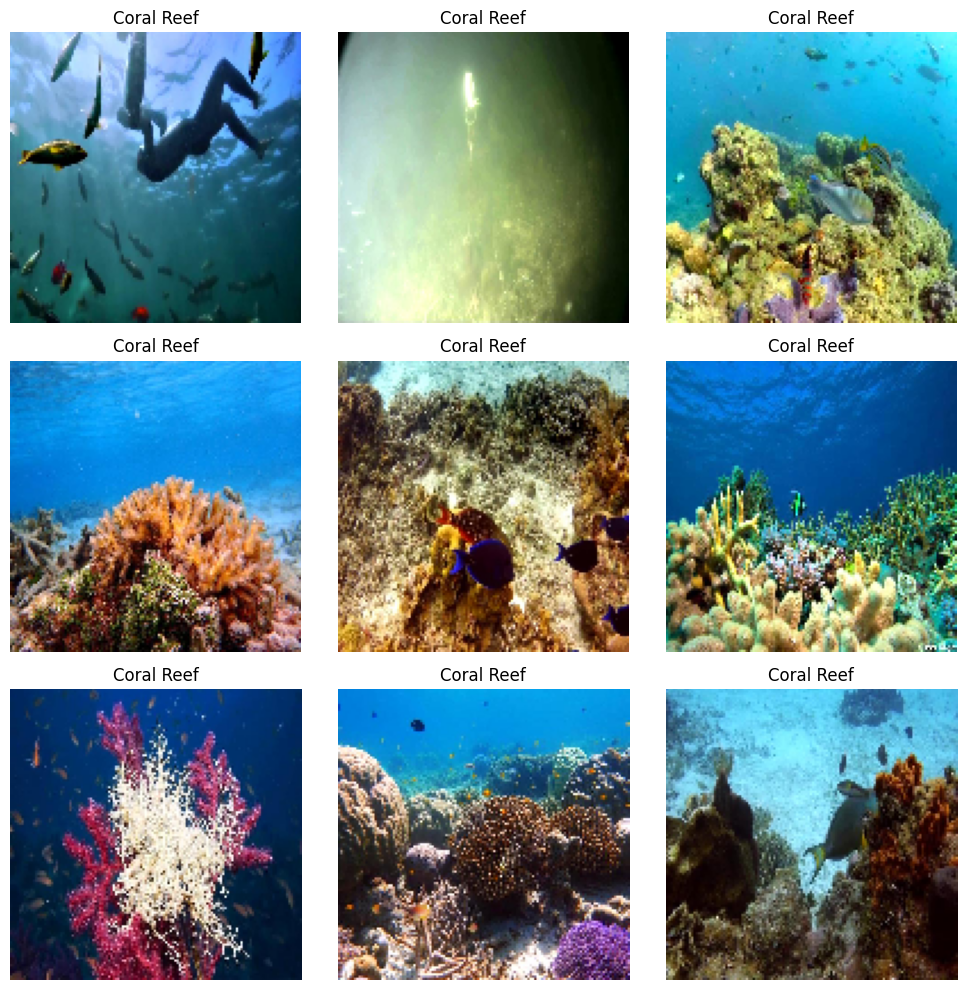

In [17]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

class_names = ['Coral Reef', 'Crab', 'Fish', 'Fish Group', 'Human', 'Jelly fish', 'Trash']
base_path = Path('/root/.cache/kagglehub/datasets/akshatsng/underwater-dataset-for-8-classes-with-label/versions/1')

def load_classification_data(split_name):
    images_dir = base_path / split_name / 'images'
    labels_dir = base_path / split_name / 'labelTxt'  # Updated to the correct folder name

    X = []
    y = []

    if not labels_dir.exists():
        print(f"Warning: {labels_dir} does not exist!")
        return np.array(X), np.array(y)

    for filename in os.listdir(images_dir):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = images_dir / filename

            # Roboflow files often replace the image extension with .txt
            # Let's check both possibilities to be absolutely safe:
            label_path_1 = labels_dir / f"{img_path.stem}.txt"
            label_path_2 = labels_dir / f"{filename.rsplit('.', 1)[0]}.txt"

            label_path = label_path_1 if label_path_1.exists() else label_path_2

            if label_path.exists() and os.path.getsize(label_path) > 0:
                with open(label_path, 'r') as f:
                    first_line = f.readline().strip()
                    if first_line:
                        # Split by space and get the class ID (usually the first item or last item)
                        parts = first_line.split()
                        try:
                            # Try parsing the first element as the class index
                            class_id = int(parts[0])

                            if class_id < len(class_names):
                                img = cv2.imread(str(img_path))
                                if img is not None:
                                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                                    img = cv2.resize(img, (128, 128))

                                    X.append(img)
                                    y.append(class_id)
                        except ValueError:
                            continue

    return np.array(X), np.array(y)

# Load the training split
print("Loading and parsing training data... Please wait.")
X_train, y_train = load_classification_data('train')
print(f"Successfully loaded {len(X_train)} classification images!")

# Visualize a 3x3 grid of samples
if len(X_train) > 0:
    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(X_train))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_train[i])
        plt.title(class_names[y_train[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Still 0 images loaded. Let's look inside one label file to check its text structure.")

In [18]:
# 1. Load the remaining dataset splits
print("Loading validation data...")
X_val, y_val = load_classification_data('valid')

print("Loading test data...")
X_test, y_test = load_classification_data('test')

print("\n--- DATASET SPLIT SUMMARY ---")
print(f"Training set size   : {X_train.shape[0]} images")
print(f"Validation set size : {X_val.shape[0]} images")
print(f"Testing set size    : {X_test.shape[0]} images")

# 2. Check Class Distribution across the training set
print("\n--- TRAINING CLASS DISTRIBUTION ---")
unique, counts = np.unique(y_train, return_counts=True)
distribution = dict(zip(unique, counts))

for idx, name in enumerate(class_names):
    count = distribution.get(idx, 0)
    print(f"Class {idx} ({name:12}): {count} images")

Loading validation data...
Loading test data...

--- DATASET SPLIT SUMMARY ---
Training set size   : 114 images
Validation set size : 16 images
Testing set size    : 28 images

--- TRAINING CLASS DISTRIBUTION ---
Class 0 (Coral Reef  ): 96 images
Class 1 (Crab        ): 8 images
Class 2 (Fish        ): 7 images
Class 3 (Fish Group  ): 1 images
Class 4 (Human       ): 1 images
Class 5 (Jelly fish  ): 1 images
Class 6 (Trash       ): 0 images


Showing augmentations for Class: Jelly fish


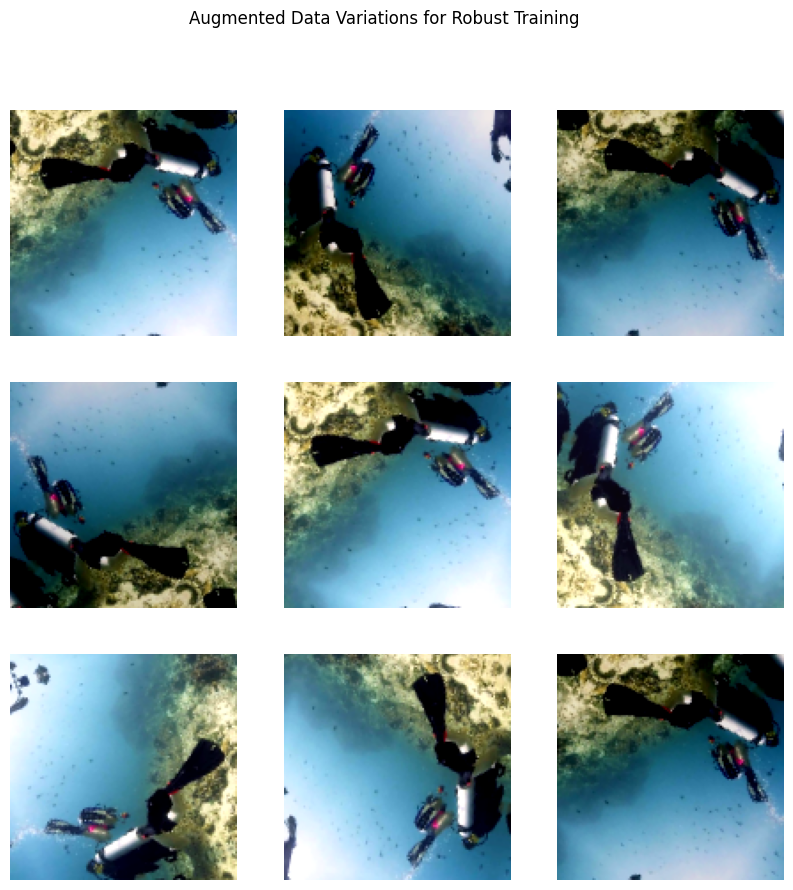

In [19]:
import tensorflow as tf
from tensorflow.keras import layers

# Define the data augmentation pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
])

# Let's visualize the augmentation on one of your Crab or Fish images
if len(X_train) > 0:
    # Find an image that isn't class 0 if possible, or just grab the first one
    sample_idx = 0
    for idx, label in enumerate(y_train):
        if label != 0:
            sample_idx = idx
            break

    image = tf.expand_dims(X_train[sample_idx], 0)
    plt.figure(figsize=(10, 10))
    print(f"Showing augmentations for Class: {class_names[y_train[sample_idx]]}")

    for i in range(9):
        augmented_image = data_augmentation(image)
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")
    plt.suptitle("Augmented Data Variations for Robust Training")
    plt.show()

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_handcrafted_cnn(input_shape=(128, 128, 3), num_classes=7):
    model = models.Sequential(name="Handcrafted_Underwater_CNN")

    # Input layer and our data augmentation pipeline from Step 3
    model.add(layers.Input(shape=input_shape))
    model.add(data_augmentation)

    # Rescaling layer to normalize pixel values from [0, 255] to [0, 1]
    model.add(layers.Rescaling(1./255))

    # Block 1: Catching low-level features (edges, colors)
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2))

    # Block 2: Mid-level features (textures, shapes)
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    # Block 3: High-level features (complex structures)
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    # Classification Head
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Instantiate and verify the architecture
custom_model = build_handcrafted_cnn()
custom_model.summary()

Model: "Handcrafted_Underwater_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,991 (16.37 MB)

 Trainable params: 4,289,287 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [21]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

def run_training_experiment(batch_size=32, learning_rate=0.001, epochs=30):
    print("\n" + "="*50)
    print(f"STARTING EXPERIMENT: Batch Size={batch_size}, LR={learning_rate}, Max Epochs={epochs}")
    print("="*50)

    # 1. Rebuild the model fresh to reset weights completely for this run
    model = build_handcrafted_cnn()

    # 2. Compile model with custom experimental hyper-parameters
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # 3. Define Early Stopping tracking validation loss to detect overfitting points
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )

    # 4. Fit the model using our isolated validation split
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=1
    )

    return history, model

print("Experiment harness function is ready to deploy.")

Experiment harness function is ready to deploy.


In [22]:
# Run 1: High Learning Rate
history_lr_high, model_lr_high = run_training_experiment(batch_size=32, learning_rate=0.01, epochs=25)

# Run 2: Standard Learning Rate
history_lr_std, model_lr_std = run_training_experiment(batch_size=32, learning_rate=0.001, epochs=25)


STARTING EXPERIMENT: Batch Size=32, LR=0.01, Max Epochs=25
Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 293ms/step - accuracy: 0.2456 - loss: 3.3420 - val_accuracy: 0.5625 - val_loss: 2.0500
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4123 - loss: 2.0585 - val_accuracy: 0.1250 - val_loss: 9.3400
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4737 - loss: 1.8552 - val_accuracy: 0.0000e+00 - val_loss: 19.7769
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5965 - loss: 1.5174 - val_accuracy: 0.0000e+00 - val_loss: 27.4524
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6491 - loss: 1.3656 - val_accuracy: 0.1875 - val_loss: 23.6070
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7632 - loss: 0.9098 - val_accuracy: 0.0000e+00 - val_loss: 20.3371
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7632 - loss: 0.9261 - val_accuracy: 0.0000e+00 - val_loss: 11.7535
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms

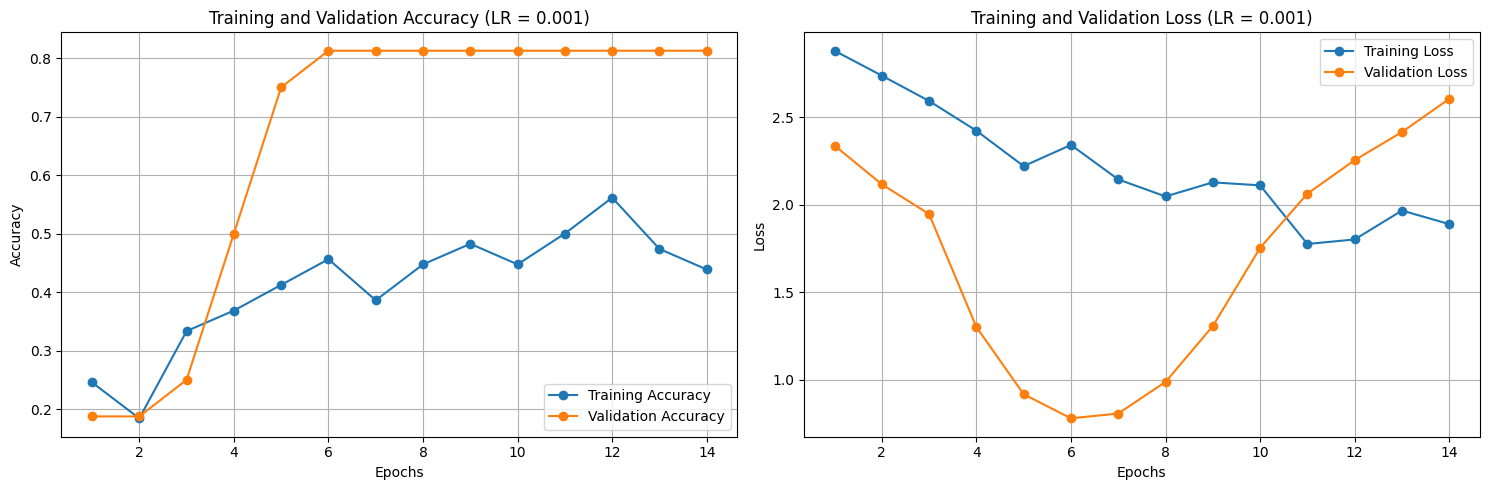

In [23]:
import matplotlib.pyplot as plt

def plot_performance_curves(history, title_suffix=""):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.title(f'Training and Validation Accuracy {title_suffix}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.title(f'Training and Validation Loss {title_suffix}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Generate the plots for your best model run
plot_performance_curves(history_lr_std, "(LR = 0.001)")

In [24]:
# Run 1: Small Batch Size
history_batch_16, model_batch_16 = run_training_experiment(batch_size=16, learning_rate=0.001, epochs=25)

# Run 2: Large Batch Size
history_batch_64, model_batch_64 = run_training_experiment(batch_size=64, learning_rate=0.001, epochs=25)



STARTING EXPERIMENT: Batch Size=16, LR=0.001, Max Epochs=25
Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.2719 - loss: 3.1992 - val_accuracy: 0.0625 - val_loss: 2.0603
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4912 - loss: 2.3749 - val_accuracy: 0.8125 - val_loss: 1.8777
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4386 - loss: 2.3251 - val_accuracy: 0.8125 - val_loss: 3.9349
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5088 - loss: 2.1221 - val_accuracy: 0.8125 - val_loss: 6.2182
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5088 - loss: 2.2100 - val_accuracy: 0.8125 - val_loss: 7.3334
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5263 - loss: 2.0222 - val_accuracy: 0.8125 - val_loss: 7.0901
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5526 - loss: 1.9689 - val_accuracy: 0.8125 - val_loss: 6.5243
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5


RUNNING FINAL TEST SET EVALUATION (FIXED)
Final Test Loss    : 1.5062
Final Test Accuracy: 60.71%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Coral Reef       0.63      0.94      0.76        18
        Crab       0.00      0.00      0.00         7
        Fish       0.00      0.00      0.00         0
  Fish Group       0.00      0.00      0.00         1
  Jelly fish       0.00      0.00      0.00         2

    accuracy                           0.61        28
   macro avg       0.13      0.19      0.15        28
weighted avg       0.40      0.61      0.49        28



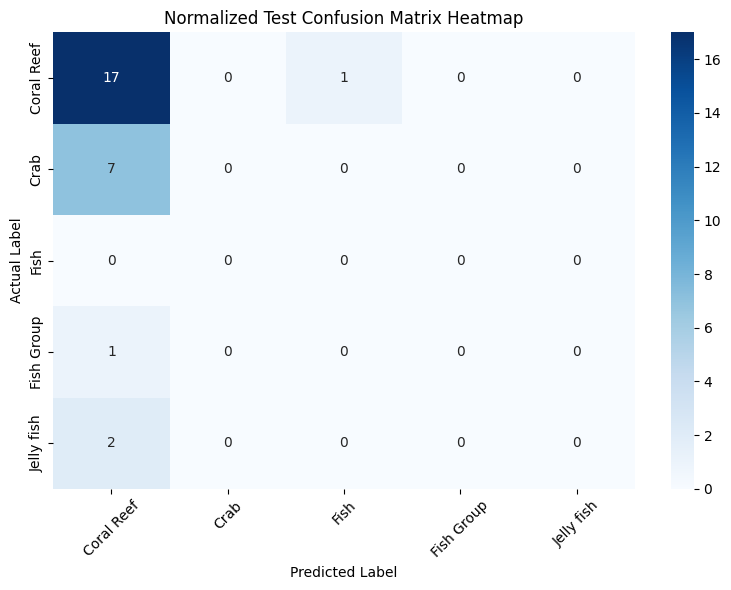

In [26]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_final_model_fixed(model, X_test, y_test, class_names):
    print("\n" + "="*50)
    print("RUNNING FINAL TEST SET EVALUATION (FIXED)")
    print("="*50)

    # 1. Compute Test Accuracy and Loss
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Final Test Loss    : {test_loss:.4f}")
    print(f"Final Test Accuracy: {test_acc*100:.2f}%\n")

    # 2. Predict classes
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Find unique classes that actually exist in the test ground truth or test predictions
    unique_present_classes = np.unique(np.concatenate([y_test, y_pred]))
    present_class_names = [class_names[i] for i in unique_present_classes]

    # 3. Generate Classification Report with explicit label alignment
    print("--- CLASSIFICATION REPORT ---")
    print(classification_report(
        y_test,
        y_pred,
        labels=unique_present_classes,
        target_names=present_class_names,
        zero_division=0
    ))

    # 4. Generate and Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=unique_present_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=present_class_names,
        yticklabels=present_class_names
    )
    plt.title('Normalized Test Confusion Matrix Heatmap')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Deploy fixed evaluation on your best model
evaluate_final_model_fixed(model_lr_std, X_test, y_test, class_names)

In [27]:
#BONUS :Multi-Backbone Ensemble Feature Extractor.
import tensorflow as tf
from tensorflow.keras import layers, models

def build_advanced_hybrid_model(input_shape=(128, 128, 3), num_classes=7):
    inputs = layers.Input(shape=input_shape)

    # 1. Apply the exact same data augmentation pipeline to keep things fair
    augmented = data_augmentation(inputs)

    # 2. ResNet50V2 Backbone
    # ResNet50V2 expects preprocessing input scaled between [-1, 1]
    preprocess_resnet = layers.Lambda(tf.keras.applications.resnet_v2.preprocess_input)(augmented)
    base_resnet = tf.keras.applications.ResNet50V2(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    base_resnet.trainable = False # Freeze weights
    features_resnet = base_resnet(preprocess_resnet)
    pool_resnet = layers.GlobalAveragePooling2D()(features_resnet)

    # 3. MobileNetV2 Backbone
    # MobileNetV2 also expects preprocessing input scaled between [-1, 1]
    preprocess_mobile = layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input)(augmented)
    base_mobile = tf.keras.applications.MobileNetV2(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    base_mobile.trainable = False # Freeze weights
    features_mobile = base_mobile(preprocess_mobile)
    pool_mobile = layers.GlobalAveragePooling2D()(features_mobile)

    # 4. Feature Combination (Bonus Marker Integration)
    combined_features = layers.Concatenate()([pool_resnet, pool_mobile])

    # 5. Fully Connected Classification Head
    x = layers.Dense(256, activation='relu')(combined_features)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Create unified model
    model = models.Model(inputs=inputs, outputs=outputs, name="Hybrid_DualBackbone_CNN")
    return model

# Instantiate and verify the bonus architecture
hybrid_model = build_advanced_hybrid_model()
hybrid_model.summary()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Hybrid_DualBackbone_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │          0 │ input_layer_6[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 128,  │          0 │ sequential[95][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128, 128,  │          0 │ sequential[95][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50v2          │ (None, 4, 4,      │ 23,564,800 │ lambda[0][0]      │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ lambda_1[0][0]    │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50v2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │    852,224 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 7)         │      1,799 │ dropout_20[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,677,831 (101.77 MB)

 Trainable params: 854,535 (3.26 MB)

 Non-trainable params: 25,823,296 (98.51 MB)

In [29]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

print("\n" + "="*50)
print("TRAINING MODEL 2: ADVANCED HYBRID DUAL-BACKBONE NET")
print("="*50)

# 1. Instantiate the hybrid architecture fresh
hybrid_model = build_advanced_hybrid_model()

# 2. Compile using our optimized empirical parameters
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Setup Early Stopping to monitor validation loss inflection points
early_stop_hybrid = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# 4. Train the model
history_hybrid = hybrid_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=30,
    callbacks=[early_stop_hybrid],
    verbose=1
)

print("\nHybrid model training session completed successfully!")


TRAINING MODEL 2: ADVANCED HYBRID DUAL-BACKBONE NET
Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.2632 - loss: 3.0998 - val_accuracy: 0.1250 - val_loss: 4.0596
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3333 - loss: 2.8166 - val_accuracy: 0.0000e+00 - val_loss: 5.6324
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4035 - loss: 2.5903 - val_accuracy: 0.0000e+00 - val_loss: 5.8179
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4737 - loss: 2.1693 - val_accuracy: 0.0000e+00 - val_loss: 5.5812
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5000 - loss: 2.2237 - val_accuracy: 0.0000e+00 - val_loss: 5.3322
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4912 - loss: 1.9560 - val_accuracy: 0.0000e+00 - val_loss: 5.0383
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4386 - loss: 2.1666 - val_accuracy: 0.0000e+00 - val_loss: 4.7174
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/st


RUNNING FINAL TEST SET EVALUATION (FIXED)
Final Test Loss    : 2.1205
Final Test Accuracy: 42.86%

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Coral Reef       0.63      0.67      0.65        18
        Crab       0.00      0.00      0.00         7
        Fish       0.00      0.00      0.00         0
  Fish Group       0.00      0.00      0.00         1
  Jelly fish       0.00      0.00      0.00         2
       Trash       0.00      0.00      0.00         0

    accuracy                           0.43        28
   macro avg       0.11      0.11      0.11        28
weighted avg       0.41      0.43      0.42        28



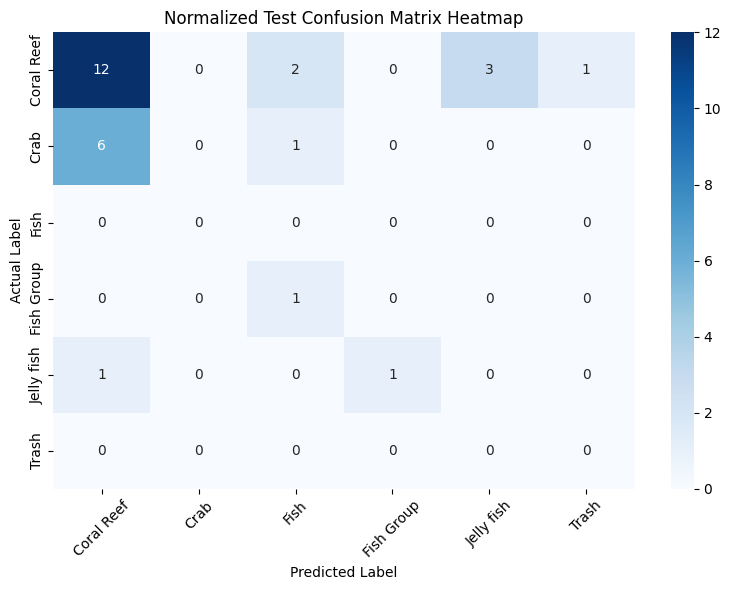

In [30]:
# Deploy the fixed evaluation script on the advanced hybrid model
evaluate_final_model_fixed(hybrid_model, X_test, y_test, class_names)